In [ ]:
# 导入数据处理相关库
import pandas as pd  # 数据框操作和CSV文件读取
import numpy as np  # 数值计算和数组操作

# 导入数据可视化库
import matplotlib.pyplot as plt  # 基础绘图库
import seaborn as sns

# 导入机器学习相关库
from sklearn.model_selection import train_test_split  # 划分训练集和测试集
from sklearn.preprocessing import StandardScaler  # 特征标准化
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier  # 三种集成学习分类器
from sklearn.tree import DecisionTreeClassifier  # 决策树分类器，作为Bagging的基学习器
from sklearn.linear_model import LogisticRegression  # 逻辑回归，作为Voting的一个基学习器
from sklearn.svm import SVC  # 支持向量机，作为Voting的另一个基学习器

# 导入模型评估相关库
from sklearn.metrics import (
    classification_report,  # 生成分类报告，包含精确率、召回率、F1分数
    confusion_matrix,  # 生成混淆矩阵
    accuracy_score  # 计算准确率
)

# 设置随机种子，确保实验可重复性
RANDOM_STATE = 42

# 设置matplotlib显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']  # 正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号
# 设置图表风格
sns.set_style("whitegrid")  # 使用白色网格背景
plt.rcParams['figure.figsize'] = (12, 8)  # 设置默认图表大小

In [187]:
# 从本地CSV文件读取数据
data = pd.read_csv('CTG.NAOMIT.csv')

print(f"数据集形状——")
print(data.shape)
print(f"\n前5行数据预览：")
print(data.head())

# 检查缺失值
print("\n缺失值检查：")
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "没有缺失值")

# 检查目标变量的分布
print("\n目标变量(NSP)的分布情况：")
print(data['NSP'].value_counts().sort_index())

数据集形状——
(2126, 23)

前5行数据预览：
    LB        AC   FM        UC        DL   DS   DP  ASTV  MSTV  ALTV  ...  \
0  120  0.000000  0.0  0.000000  0.000000  0.0  0.0    73   0.5    43  ...   
1  132  0.006380  0.0  0.006380  0.003190  0.0  0.0    17   2.1     0  ...   
2  133  0.003322  0.0  0.008306  0.003322  0.0  0.0    16   2.1     0  ...   
3  134  0.002561  0.0  0.007682  0.002561  0.0  0.0    16   2.4     0  ...   
4  132  0.006515  0.0  0.008143  0.000000  0.0  0.0    16   2.4     0  ...   

   Max  Nmax  Nzeros  Mode  Mean  Median  Variance  Tendency  CLASS  NSP  
0  126     2       0   120   137     121        73         1      9    2  
1  198     6       1   141   136     140        12         0      6    1  
2  198     5       1   141   135     138        13         0      6    1  
3  170    11       0   137   134     137        13         1      6    1  
4  170     9       0   137   136     138        11         1      2    1  

[5 rows x 23 columns]

缺失值检查：
没有缺失值

目标变量(NSP)的分布情况

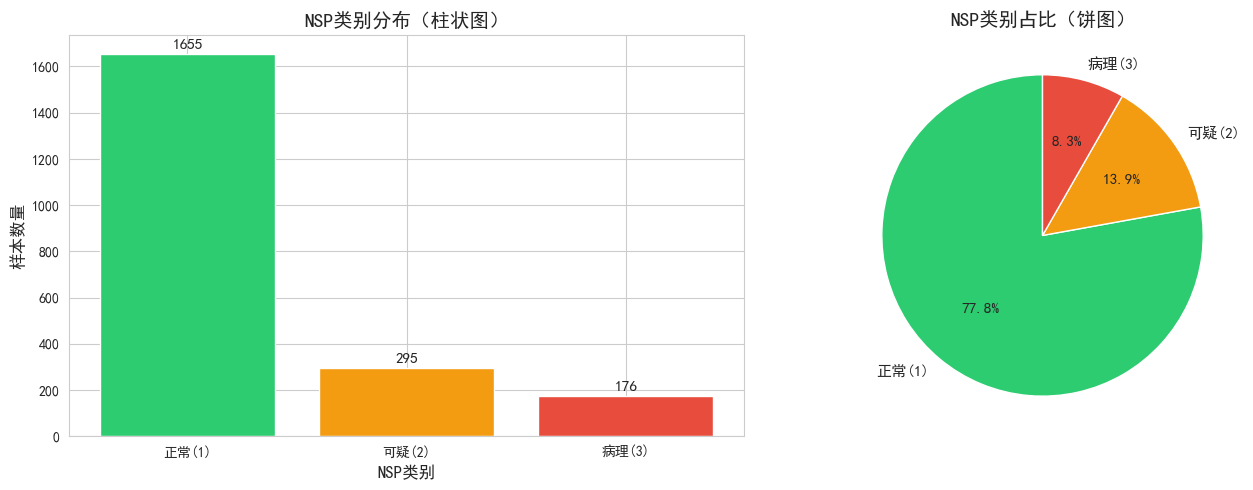

In [188]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'SimHei'     # 使用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号
# 创建一个包含两个子图的画布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 子图1：柱状图显示各类别的样本数量
nsp_counts = data['NSP'].value_counts().sort_index()
axes[0].bar(nsp_counts.index, nsp_counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_xlabel('NSP类别', fontsize=12)
axes[0].set_ylabel('样本数量', fontsize=12)
axes[0].set_title('NSP类别分布（柱状图）', fontsize=14, fontweight='bold', fontname='SimHei')
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(['正常(1)', '可疑(2)', '病理(3)'], fontname='SimHei')
# 在柱状图上添加数值标签
for i, v in enumerate(nsp_counts.values):
    axes[0].text(i + 1, v + 20, str(v),
                 ha='center', fontsize=11, fontweight='bold', fontname='SimHei')

# 子图2：饼图显示各类别的占比
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].pie(
    nsp_counts.values,
    labels=['正常(1)', '可疑(2)', '病理(3)'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 11, 'fontname': 'SimHei'}  # 显式字体
)
axes[1].set_title('NSP类别占比（饼图）', fontsize=14, fontweight='bold', fontname='SimHei')
plt.tight_layout()
plt.show()

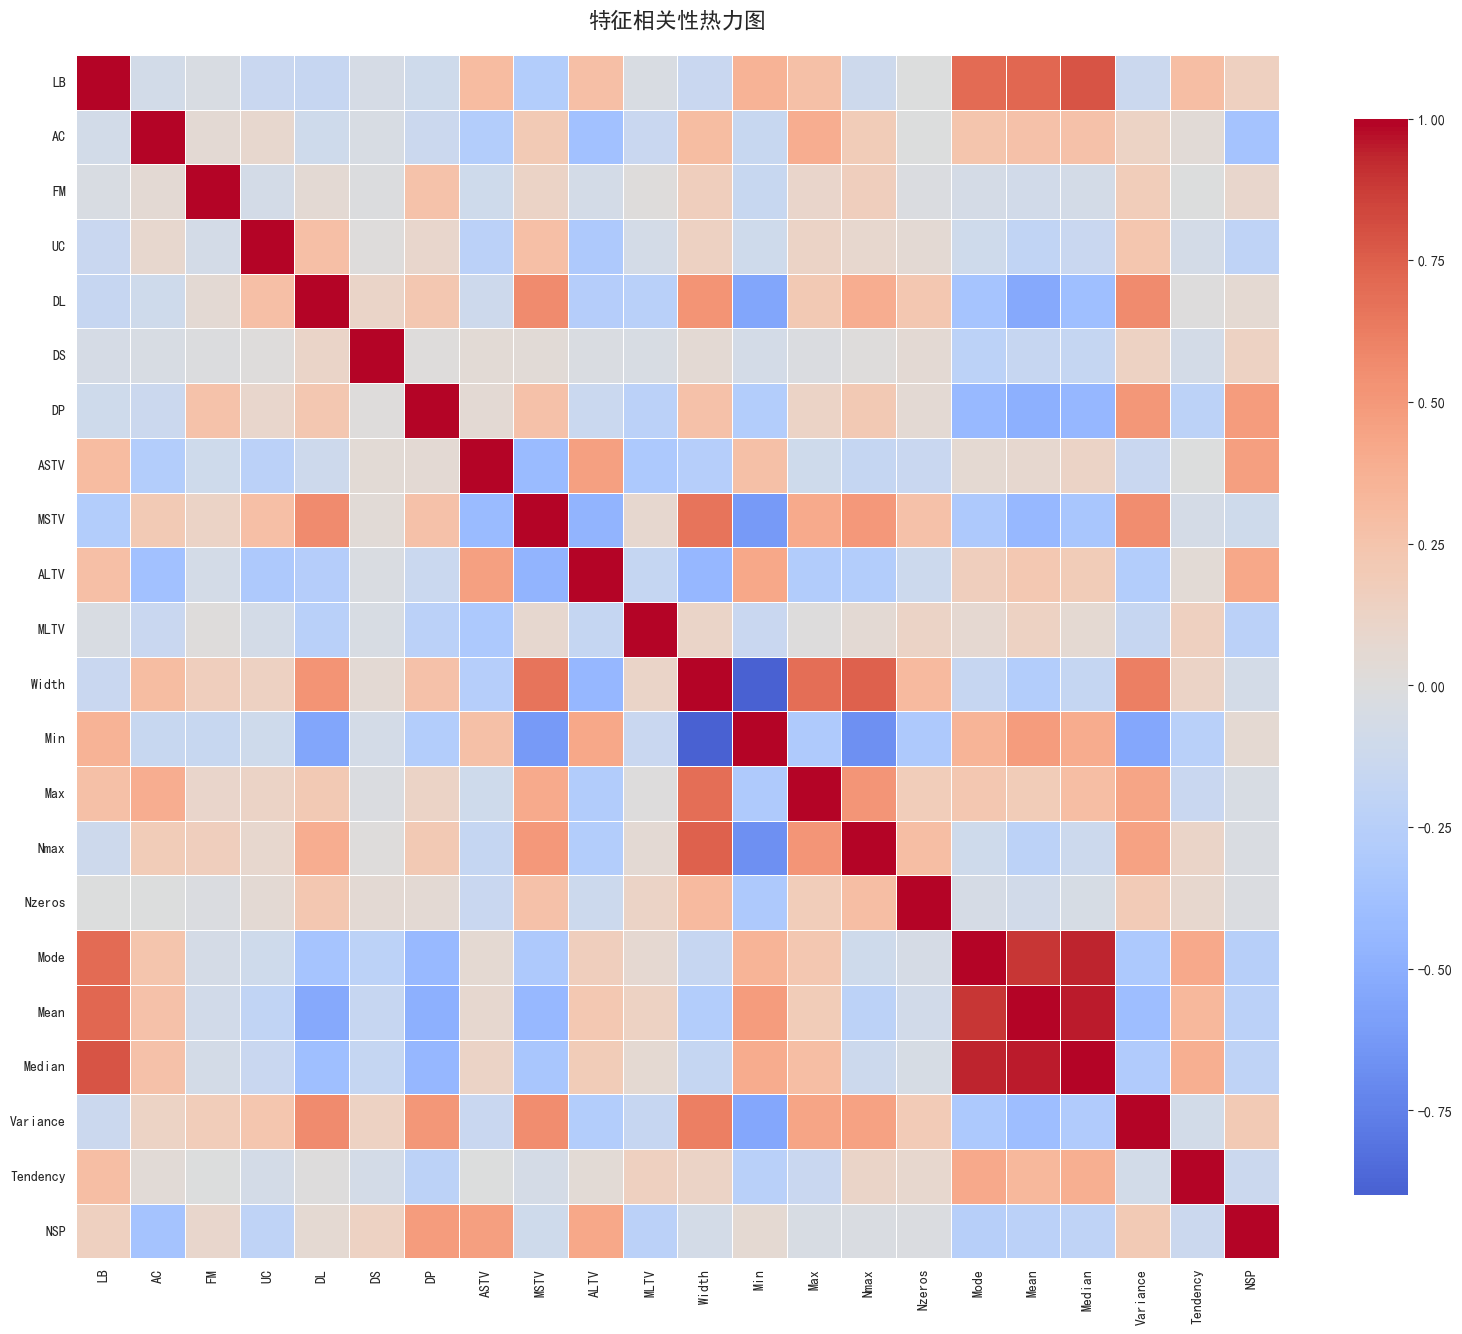


与目标变量NSP相关性最强的前10个特征：
DP: 0.4883 (正相关)
ASTV: 0.4712 (正相关)
ALTV: 0.4261 (正相关)
AC: -0.3638 (负相关)
Mode: -0.2504 (负相关)
Mean: -0.2270 (负相关)
MLTV: -0.2268 (负相关)
Variance: 0.2066 (正相关)
Median: -0.2050 (负相关)
UC: -0.2038 (负相关)


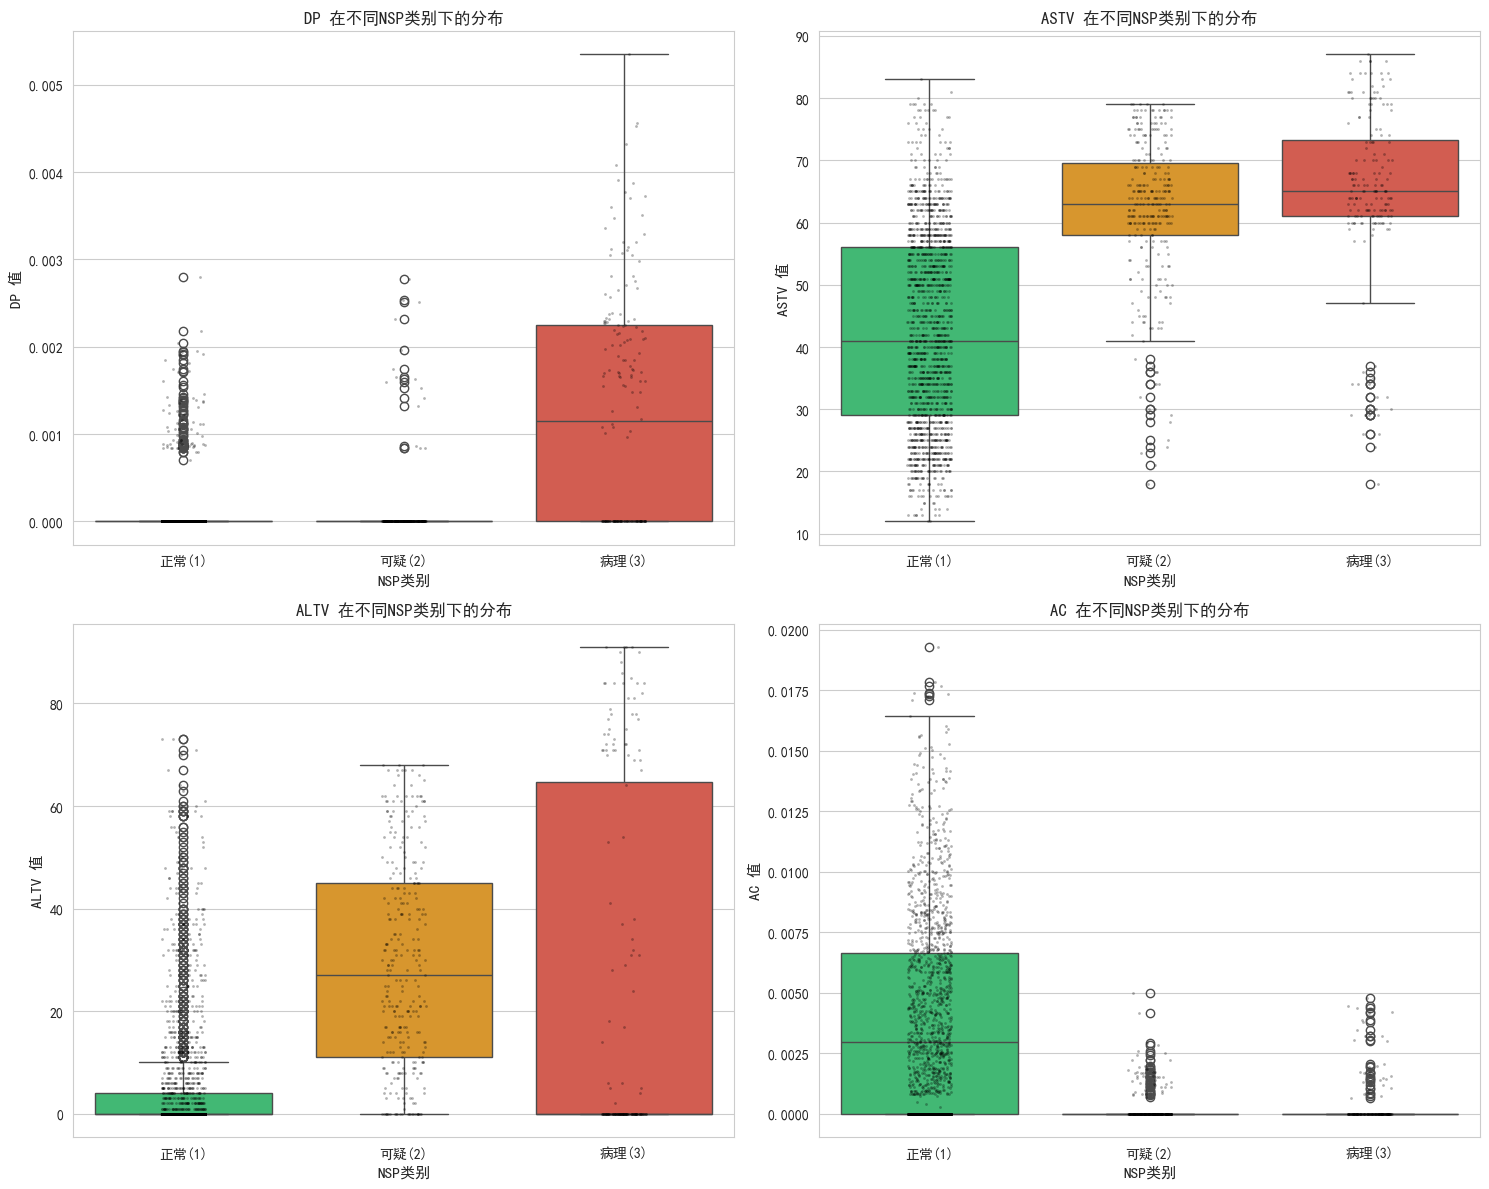

In [189]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'SimHei'     # 使用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号
# 特征相关性分析
numerical_features = data.select_dtypes(include=[np.number]).columns.tolist()
if 'CLASS' in numerical_features and 'CLASS' != 'NSP':
    numerical_features.remove('CLASS')

correlation_matrix = data[numerical_features].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('特征相关性热力图', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

corr_with_nsp = correlation_matrix['NSP'].sort_values(
    key=lambda x: x.abs(),  # 排序按绝对值
    ascending=False
)
top_features = corr_with_nsp[1:11]  # 前10个（跳过 NSP 自身）
print("\n与目标变量NSP相关性最强的前10个特征：")
for feature, corr in top_features.items():
    trend = "正相关" if corr > 0 else "负相关"
    print(f"{feature}: {corr:.4f} ({trend})")

# 重要特征在不同NSP类别下的分布（箱线图）
top_4_features = top_features.head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()
# 定义统一颜色
colors = ['#2ecc71', '#f39c12', '#e74c3c']
for idx, feature in enumerate(top_4_features):
    # 使用hue代替直接palette，避免FutureWarning
    sns.boxplot(x='NSP', y=feature, data=data, ax=axes[idx],
                hue='NSP', palette=colors, dodge=False, showfliers=True, legend=False)
    axes[idx].set_title(f'{feature} 在不同NSP类别下的分布', fontsize=12, fontweight='bold', fontname='SimHei')
    axes[idx].set_xlabel('NSP类别', fontsize=11)
    axes[idx].set_ylabel(f'{feature} 值', fontsize=11)
    axes[idx].set_xticks([0, 1, 2])
    axes[idx].set_xticklabels(['正常(1)', '可疑(2)', '病理(3)'], fontname='SimHei')
    # 添加散点
    sns.stripplot(x='NSP', y=feature, data=data, ax=axes[idx],
                  color='black', alpha=0.3, size=2, dodge=True)

plt.tight_layout()
plt.show()

In [190]:
# 数据预处理
# 分离特征和目标
columns_to_exclude = ['NSP'] + (['CLASS'] if 'CLASS' in data.columns else [])
X = data.drop(columns=columns_to_exclude)
y = data['NSP']
# 划分训练集和测试集
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
# 特征标准化
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [191]:
# 随机森林模型训练与评估
# 创建随机森林分类器
rf_basic = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'  # 处理类别不平衡
)
# 训练模型
rf_basic.fit(X_train_scaled, y_train)

# 在训练集上预测
y_train_pred_rf = rf_basic.predict(X_train_scaled)
# 在测试集上预测
y_test_pred_rf = rf_basic.predict(X_test_scaled)

# 返回每个样本属于各个类别的概率
y_test_pred_proba_rf = rf_basic.predict_proba(X_test_scaled)

# 计算训练集和测试集的准确率
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

print(f"\n准确率(Accuracy)：")
print(f"  训练集准确率：{train_accuracy_rf:.4f} ({train_accuracy_rf*100:.2f}%)")
print(f"  测试集准确率：{test_accuracy_rf:.4f} ({test_accuracy_rf*100:.2f}%)\n")

# 生成详细的分类报告
class_report_rf = classification_report(y_test, y_test_pred_rf, 
                                        target_names=['正常(1)', '可疑(2)', '病理(3)'])
print(class_report_rf)


准确率(Accuracy)：
  训练集准确率：0.9994 (99.94%)
  测试集准确率：0.9319 (93.19%)

              precision    recall  f1-score   support

       正常(1)       0.94      0.98      0.96       332
       可疑(2)       0.85      0.69      0.77        59
       病理(3)       0.91      0.89      0.90        35

    accuracy                           0.93       426
   macro avg       0.90      0.85      0.88       426
weighted avg       0.93      0.93      0.93       426




前15个最重要的特征：
    特征名称      重要性
    ASTV 0.127043
    ALTV 0.114567
    Mean 0.088282
  Median 0.077919
    MSTV 0.077028
      AC 0.070513
      DP 0.067866
    MLTV 0.061750
    Mode 0.052560
Variance 0.048732
      LB 0.044368
   Width 0.030855
      UC 0.030696
     Min 0.027177
     Max 0.026268


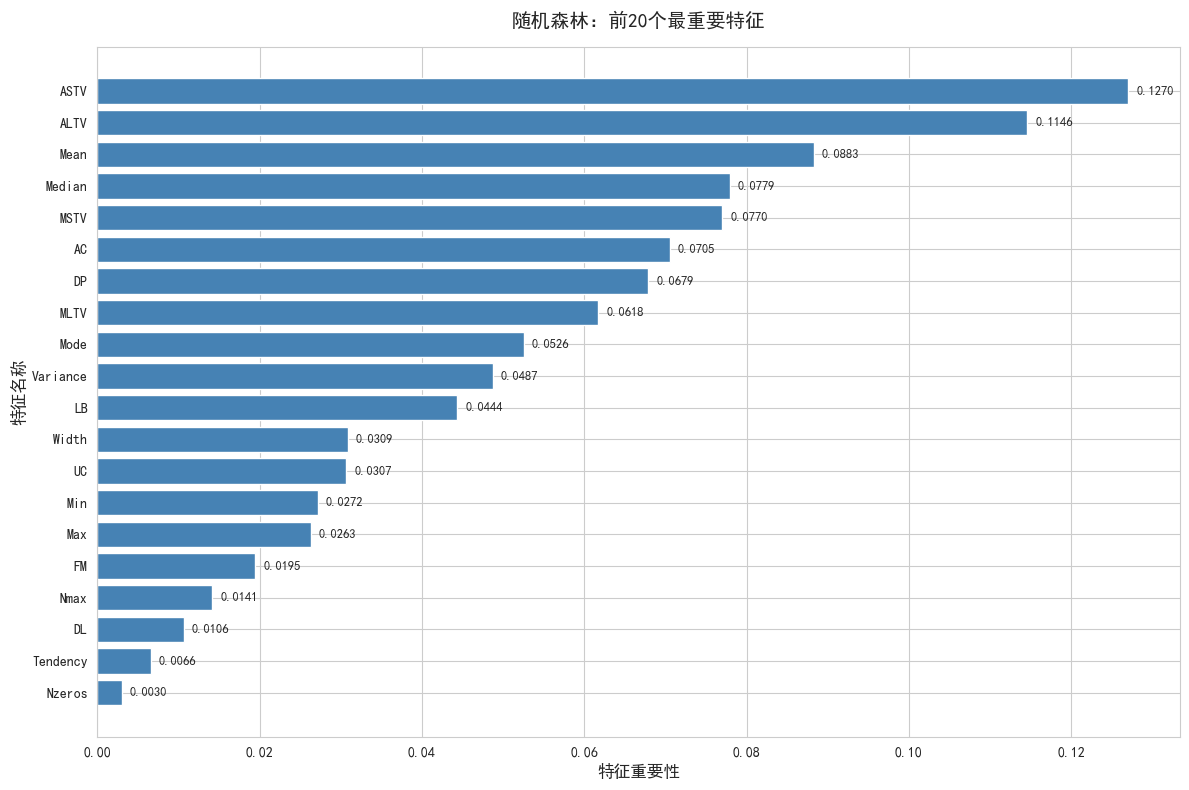

In [192]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'SimHei'     # 使用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False # 正常显示负号

# 获取特征重要性
feature_importances_rf = rf_basic.feature_importances_

# 创建特征重要性数据框并排序
feature_importance_df_rf = pd.DataFrame({
    '特征名称': X.columns,
    '重要性': feature_importances_rf
}).sort_values('重要性', ascending=False)

print("\n前15个最重要的特征：")
print(feature_importance_df_rf.head(15).to_string(index=False))

# 可视化特征重要性
plt.figure(figsize=(12, 8))
# 绘制前20个最重要特征的条形图
top_n = 20
top_features_rf = feature_importance_df_rf.head(top_n)

# 使用水平条形图，便于阅读特征名称
plt.barh(range(top_n), top_features_rf['重要性'].values, color='steelblue')
plt.yticks(range(top_n), top_features_rf['特征名称'].values)
plt.xlabel('特征重要性', fontsize=12)
plt.ylabel('特征名称', fontsize=12)
plt.title(f'随机森林：前{top_n}个最重要特征', fontsize=14, fontweight='bold', pad=15)
plt.gca().invert_yaxis()  # 倒序排列，使重要性最高的特征在顶部

# 添加数值标签
for i, v in enumerate(top_features_rf['重要性'].values):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()


Hard Voting分类器测试集准确率：0.8850 (88.50%)

Soft Voting分类器测试集准确率：0.9038 (90.38%)

每个基学习器单独的性能：

1. 随机森林单独准确率：     0.9319 (93.19%)
2. 逻辑回归单独准确率：     0.8545 (85.45%)
3. 支持向量机单独准确率：   0.8826 (88.26%)

4. Hard Voting集成准确率：  0.8850 (88.50%)
5. Soft Voting集成准确率：  0.9038 (90.38%)

集成效果分析：
  最佳单模型准确率：0.9319
  Hard Voting提升：-4.69%
  Soft Voting提升：-2.82%


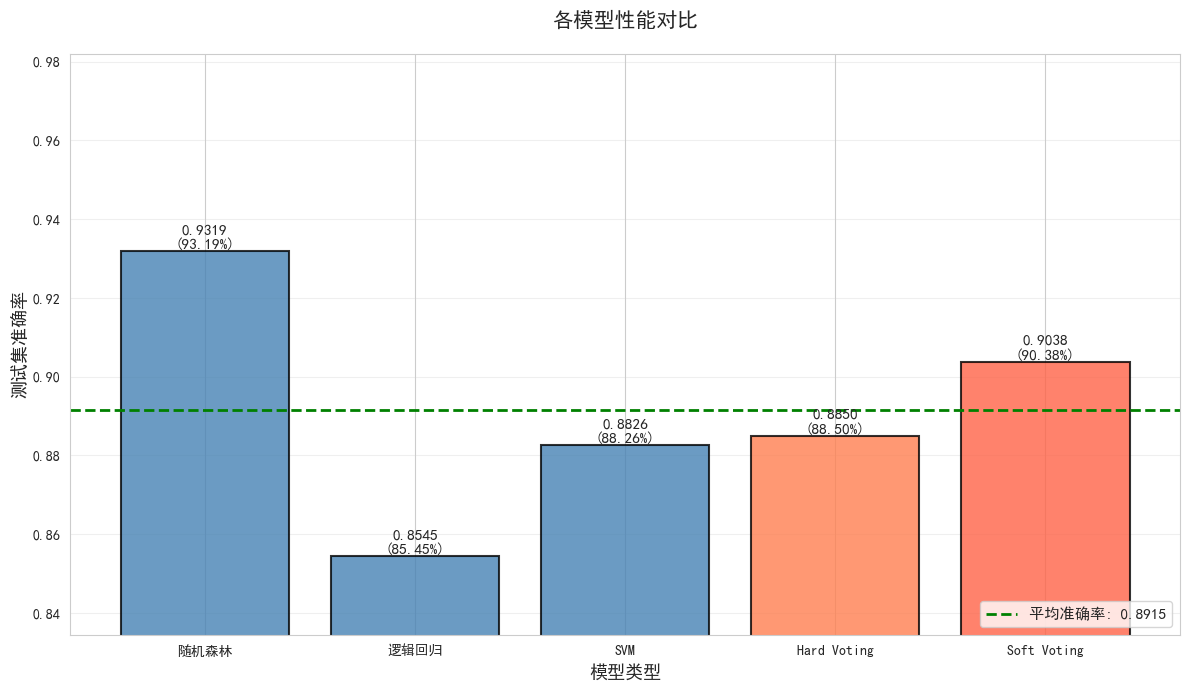

In [193]:
# Voting集成分类器训练与评估
# 定义Voting分类器的基学习器

# 基学习器1：随机森林
rf_for_voting = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight='balanced'  # 处理类别不平衡
)
# 基学习器2：逻辑回归
lr_for_voting = LogisticRegression(
    C=1.0,  # 正则化参数
    max_iter=1000,  # 最大迭代次数
    random_state=RANDOM_STATE,
    class_weight='balanced',  # 处理类别不平衡
    n_jobs=-1
)
# 基学习器3：支持向量机（SVM）
svm_for_voting = SVC(
    C=1.0,  # 惩罚参数
    kernel='rbf',  # 径向基函数核
    probability=True,  # 启用概率估计，用于soft voting
    random_state=RANDOM_STATE,
    class_weight='balanced'  # 处理类别不平衡
)

# 创建Voting分类器（Hard Voting）
# voting='hard'：使用硬投票策略
voting_hard = VotingClassifier(
    estimators=[
        ('rf', rf_for_voting),    # 随机森林
        ('lr', lr_for_voting),    # 逻辑回归
        ('svm', svm_for_voting)   # 支持向量机
    ],
    voting='hard',  # 硬投票
    n_jobs=-1
)

voting_hard.fit(X_train_scaled, y_train)

# 预测
y_test_pred_voting_hard = voting_hard.predict(X_test_scaled)
test_accuracy_voting_hard = accuracy_score(y_test, y_test_pred_voting_hard)

print(f"\nHard Voting分类器测试集准确率：{test_accuracy_voting_hard:.4f} "
      f"({test_accuracy_voting_hard*100:.2f}%)")

# 创建Voting分类器（Soft Voting）
# voting='soft'：使用软投票策略
voting_soft = VotingClassifier(
    estimators=[
        ('rf', rf_for_voting),    # 随机森林
        ('lr', lr_for_voting),    # 逻辑回归
        ('svm', svm_for_voting)   # 支持向量机
    ],
    voting='soft',  # 软投票
    n_jobs=-1
)
voting_soft.fit(X_train_scaled, y_train)

# 预测
y_test_pred_voting_soft = voting_soft.predict(X_test_scaled)
y_test_pred_proba_voting_soft = voting_soft.predict_proba(X_test_scaled)
test_accuracy_voting_soft = accuracy_score(y_test, y_test_pred_voting_soft)

print(f"\nSoft Voting分类器测试集准确率：{test_accuracy_voting_soft:.4f} "
      f"({test_accuracy_voting_soft*100:.2f}%)")

# 评估各个基学习器的单独性能
print("\n每个基学习器单独的性能：")
# 评估随机森林
rf_for_voting.fit(X_train_scaled, y_train)
y_test_pred_rf_alone = rf_for_voting.predict(X_test_scaled)
acc_rf_alone = accuracy_score(y_test, y_test_pred_rf_alone)
print(f"\n1. 随机森林单独准确率：     {acc_rf_alone:.4f} ({acc_rf_alone*100:.2f}%)")
# 评估逻辑回归
lr_for_voting.fit(X_train_scaled, y_train)
y_test_pred_lr_alone = lr_for_voting.predict(X_test_scaled)
acc_lr_alone = accuracy_score(y_test, y_test_pred_lr_alone)
print(f"2. 逻辑回归单独准确率：     {acc_lr_alone:.4f} ({acc_lr_alone*100:.2f}%)")
# 评估支持向量机
svm_for_voting.fit(X_train_scaled, y_train)
y_test_pred_svm_alone = svm_for_voting.predict(X_test_scaled)
acc_svm_alone = accuracy_score(y_test, y_test_pred_svm_alone)
print(f"3. 支持向量机单独准确率：   {acc_svm_alone:.4f} ({acc_svm_alone*100:.2f}%)")

print(f"\n4. Hard Voting集成准确率：  {test_accuracy_voting_hard:.4f} "
      f"({test_accuracy_voting_hard*100:.2f}%)")
print(f"5. Soft Voting集成准确率：  {test_accuracy_voting_soft:.4f} "
      f"({test_accuracy_voting_soft*100:.2f}%)")

# 分析集成效果
best_base_acc = max(acc_rf_alone, acc_lr_alone, acc_svm_alone)
print(f"\n集成效果分析：")
print(f"  最佳单模型准确率：{best_base_acc:.4f}")
print(f"  Hard Voting提升：{(test_accuracy_voting_hard - best_base_acc)*100:.2f}%")
print(f"  Soft Voting提升：{(test_accuracy_voting_soft - best_base_acc)*100:.2f}%")

# Voting分类器性能可视化对比
# 准备数据
models = ['随机森林', '逻辑回归', 'SVM', 'Hard Voting', 'Soft Voting']
accuracies = [acc_rf_alone, acc_lr_alone, acc_svm_alone, 
              test_accuracy_voting_hard, test_accuracy_voting_soft]

# 绘制对比图
plt.figure(figsize=(12, 7))
colors = ['steelblue', 'steelblue', 'steelblue', 'coral', 'tomato']
bars = plt.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# 添加数值标签
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}\n({acc*100:.2f}%)', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 添加平均线
avg_accuracy = np.mean(accuracies)
plt.axhline(y=avg_accuracy, color='green', linestyle='--', 
            linewidth=2, label=f'平均准确率: {avg_accuracy:.4f}')

plt.xlabel('模型类型', fontsize=13)
plt.ylabel('测试集准确率', fontsize=13)
plt.title('各模型性能对比', fontsize=15, fontweight='bold', pad=20)
plt.ylim([min(accuracies) - 0.02, max(accuracies) + 0.05])
plt.legend(fontsize=11, loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Hard Voting分类报告
              precision    recall  f1-score   support

       正常(1)       0.98      0.89      0.94       332
       可疑(2)       0.57      0.88      0.69        59
       病理(3)       0.85      0.80      0.82        35

    accuracy                           0.88       426
   macro avg       0.80      0.86      0.82       426
weighted avg       0.92      0.88      0.89       426

Hard Voting混淆矩阵：
[[297  33   2]
 [  4  52   3]
 [  1   6  28]]

Soft Voting分类报告
              precision    recall  f1-score   support

       正常(1)       0.96      0.94      0.95       332
       可疑(2)       0.64      0.78      0.70        59
       病理(3)       0.90      0.80      0.85        35

    accuracy                           0.90       426
   macro avg       0.83      0.84      0.83       426
weighted avg       0.91      0.90      0.91       426

Soft Voting混淆矩阵：
[[311  20   1]
 [ 11  46   2]
 [  1   6  28]]

各类别准确率对比表：
   类别 Hard Voting准确率 Soft Voting准确率      差异
正常(1)         89.46%  

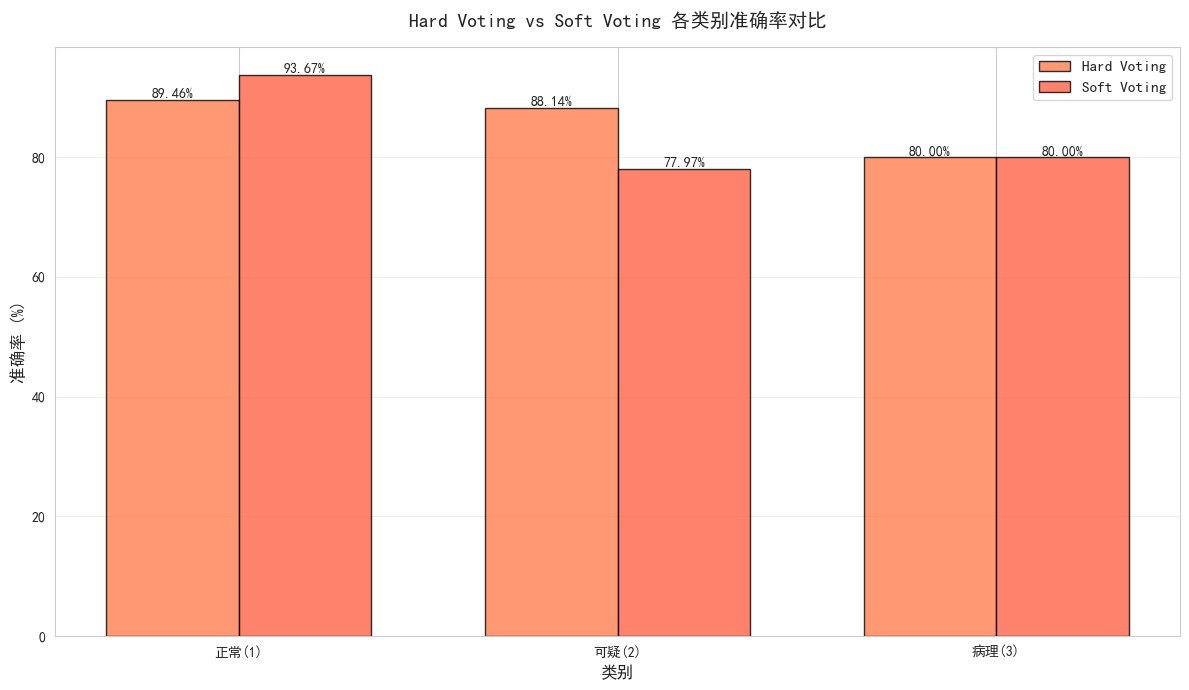

In [194]:
# Voting分类器详细评估
# Hard Voting详细分类报告
print("\nHard Voting分类报告")
print("=" * 60)
class_report_voting_hard = classification_report(
    y_test, y_test_pred_voting_hard, 
    target_names=['正常(1)', '可疑(2)', '病理(3)']
)
print(class_report_voting_hard)

# 计算Hard Voting混淆矩阵
cm_voting_hard = confusion_matrix(y_test, y_test_pred_voting_hard)
print("Hard Voting混淆矩阵：")
print(cm_voting_hard)

# Soft Voting详细分类报告
print("\nSoft Voting分类报告")
print("=" * 60)
class_report_voting_soft = classification_report(
    y_test, y_test_pred_voting_soft, 
    target_names=['正常(1)', '可疑(2)', '病理(3)']
)
print(class_report_voting_soft)

# 计算Soft Voting混淆矩阵
cm_voting_soft = confusion_matrix(y_test, y_test_pred_voting_soft)
print("Soft Voting混淆矩阵：")
print(cm_voting_soft)

# 各类别准确率对比分析
# 创建对比表格
comparison_data = []

for i, class_name in enumerate(['正常(1)', '可疑(2)', '病理(3)']):
    # 计算每个类别在不同模型下的准确率
    total = cm_voting_hard[i, :].sum()
    
    # Hard Voting
    correct_hard = cm_voting_hard[i, i]
    acc_hard = correct_hard / total * 100
    
    # Soft Voting
    correct_soft = cm_voting_soft[i, i]
    acc_soft = correct_soft / total * 100
    
    comparison_data.append({
        '类别': class_name,
        'Hard Voting准确率': f'{acc_hard:.2f}%',
        'Soft Voting准确率': f'{acc_soft:.2f}%',
        '差异': f'{acc_soft - acc_hard:+.2f}%'
    })

comparison_df = pd.DataFrame(comparison_data)
print("\n各类别准确率对比表：")
print(comparison_df.to_string(index=False))

# 可视化各类别准确率对比
fig, ax = plt.subplots(figsize=(12, 7))

classes = ['正常(1)', '可疑(2)', '病理(3)']
x = np.arange(len(classes))
width = 0.35

# 计算各类别准确率
hard_accs = [cm_voting_hard[i, i] / cm_voting_hard[i, :].sum() * 100 for i in range(3)]
soft_accs = [cm_voting_soft[i, i] / cm_voting_soft[i, :].sum() * 100 for i in range(3)]

bars1 = ax.bar(x - width/2, hard_accs, width, label='Hard Voting', 
               color='coral', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, soft_accs, width, label='Soft Voting', 
               color='tomato', alpha=0.8, edgecolor='black')

# 添加数值标签
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('类别', fontsize=12)
ax.set_ylabel('准确率 (%)', fontsize=12)
ax.set_title('Hard Voting vs Soft Voting 各类别准确率对比', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


准确率评估：
  训练集准确率：0.9829 (98.29%)
  测试集准确率：0.9296 (92.96%)

详细分类报告（测试集）：
              precision    recall  f1-score   support

       正常(1)       0.96      0.96      0.96       332
       可疑(2)       0.79      0.78      0.79        59
       病理(3)       0.89      0.89      0.89        35

    accuracy                           0.93       426
   macro avg       0.88      0.88      0.88       426
weighted avg       0.93      0.93      0.93       426


混淆矩阵（原始数值）：
[[319  11   2]
 [ 11  46   2]
 [  3   1  31]]

单个决策树测试集准确率：0.8920 (89.20%)
Bagging集成测试集准确率：0.9296 (92.96%)

Bagging提升：3.76%


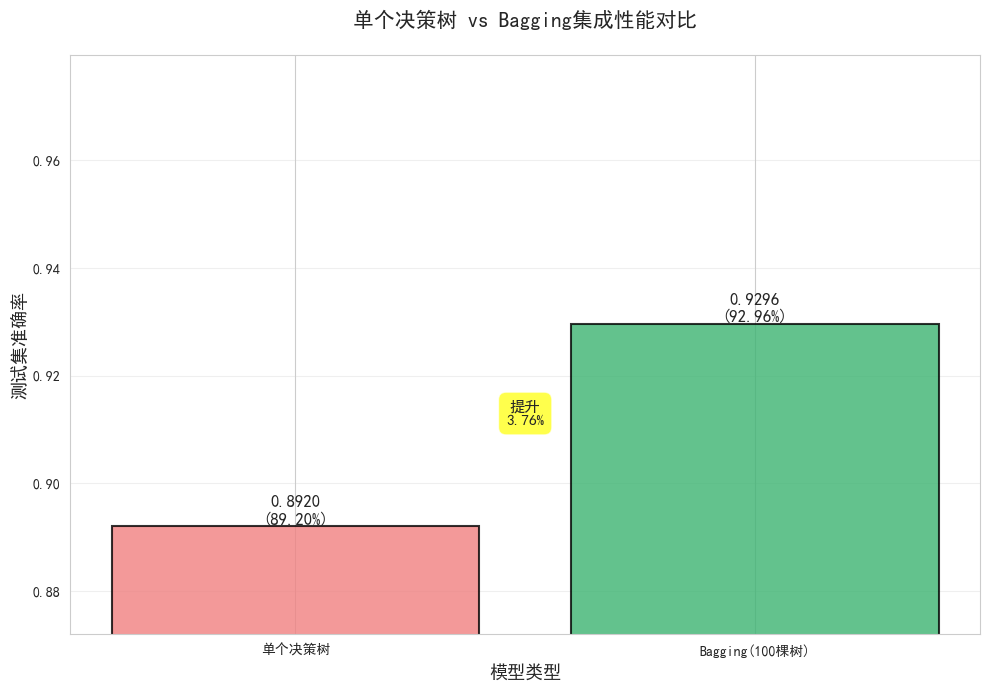

In [195]:
# 创建Bagging分类器
# 定义基学习器：决策树
# 使用决策树作为基学习器，因为决策树方差较大，适合用Bagging来降低方差
base_estimator = DecisionTreeClassifier(
    max_depth=10,  # 限制树深度
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

# 创建Bagging分类器
bagging_clf = BaggingClassifier(
    estimator=base_estimator,  # 基学习器
    n_estimators=100,  # 基学习器数量
    max_samples=0.8,  # 每次抽样的样本比例
    max_features=0.8,  # 每次抽样的特征比例
    bootstrap=True,  # 使用Bootstrap采样
    bootstrap_features=False,  # 不对特征进行Bootstrap
    oob_score=True,  # 计算袋外分数
    random_state=RANDOM_STATE,
    n_jobs=-1  # 使用所有CPU核心并行训练
)

# 训练Bagging分类器
bagging_clf.fit(X_train_scaled, y_train)

# Bagging分类器预测与评估
# 预测
y_train_pred_bagging = bagging_clf.predict(X_train_scaled)
y_test_pred_bagging = bagging_clf.predict(X_test_scaled)
y_test_pred_proba_bagging = bagging_clf.predict_proba(X_test_scaled)

# 计算准确率
train_accuracy_bagging = accuracy_score(y_train, y_train_pred_bagging)
test_accuracy_bagging = accuracy_score(y_test, y_test_pred_bagging)

print(f"\n准确率评估：")
print(f"  训练集准确率：{train_accuracy_bagging:.4f} ({train_accuracy_bagging*100:.2f}%)")
print(f"  测试集准确率：{test_accuracy_bagging:.4f} ({test_accuracy_bagging*100:.2f}%)")


# 生成详细分类报告
print("\n详细分类报告（测试集）：")
print("=" * 60)
class_report_bagging = classification_report(
    y_test, y_test_pred_bagging, 
    target_names=['正常(1)', '可疑(2)', '病理(3)']
)
print(class_report_bagging)

# 计算混淆矩阵
cm_bagging = confusion_matrix(y_test, y_test_pred_bagging)
print("\n混淆矩阵（原始数值）：")
print(cm_bagging)

# 评估单个决策树vs Bagging效果
# 训练单个决策树（与Bagging中的基学习器配置相同）
single_tree = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

single_tree.fit(X_train_scaled, y_train)
y_test_pred_single_tree = single_tree.predict(X_test_scaled)
acc_single_tree = accuracy_score(y_test, y_test_pred_single_tree)

print(f"\n单个决策树测试集准确率：{acc_single_tree:.4f} ({acc_single_tree*100:.2f}%)")
print(f"Bagging集成测试集准确率：{test_accuracy_bagging:.4f} ({test_accuracy_bagging*100:.2f}%)")
print(f"\nBagging提升：{(test_accuracy_bagging - acc_single_tree)*100:.2f}%")

# 可视化对比
models_comparison = ['单个决策树', 'Bagging(100棵树)']
accuracies_comparison = [acc_single_tree, test_accuracy_bagging]

plt.figure(figsize=(10, 7))
colors_comp = ['lightcoral', 'mediumseagreen']
bars = plt.bar(models_comparison, accuracies_comparison, color=colors_comp, 
               alpha=0.8, edgecolor='black', linewidth=1.5)

# 添加数值标签
for bar, acc in zip(bars, accuracies_comparison):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}\n({acc*100:.2f}%)', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# 添加提升幅度标注
if test_accuracy_bagging > acc_single_tree:
    mid_x = 0.5
    mid_y = (acc_single_tree + test_accuracy_bagging) / 2
    improvement = (test_accuracy_bagging - acc_single_tree) * 100
    plt.annotate(f'提升\n{improvement:.2f}%', 
                xy=(mid_x, mid_y), fontsize=11, fontweight='bold',
                ha='center', bbox=dict(boxstyle='round,pad=0.5', 
                facecolor='yellow', alpha=0.7))

plt.xlabel('模型类型', fontsize=13)
plt.ylabel('测试集准确率', fontsize=13)
plt.title('单个决策树 vs Bagging集成性能对比', fontsize=15, fontweight='bold', pad=20)
plt.ylim([min(accuracies_comparison) - 0.02, max(accuracies_comparison) + 0.05])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


所有模型准确率排名：
 排名          模型   测试集准确率 准确率(%)
  1    随机森林(基本) 0.931925 93.19%
  2     Bagging 0.929577 92.96%
  3 Voting-Soft 0.903756 90.38%
  4       单个决策树 0.892019 89.20%
  5 Voting-Hard 0.884977 88.50%

最佳模型：随机森林(基本)
  测试集准确率：0.9319 (93.19%)


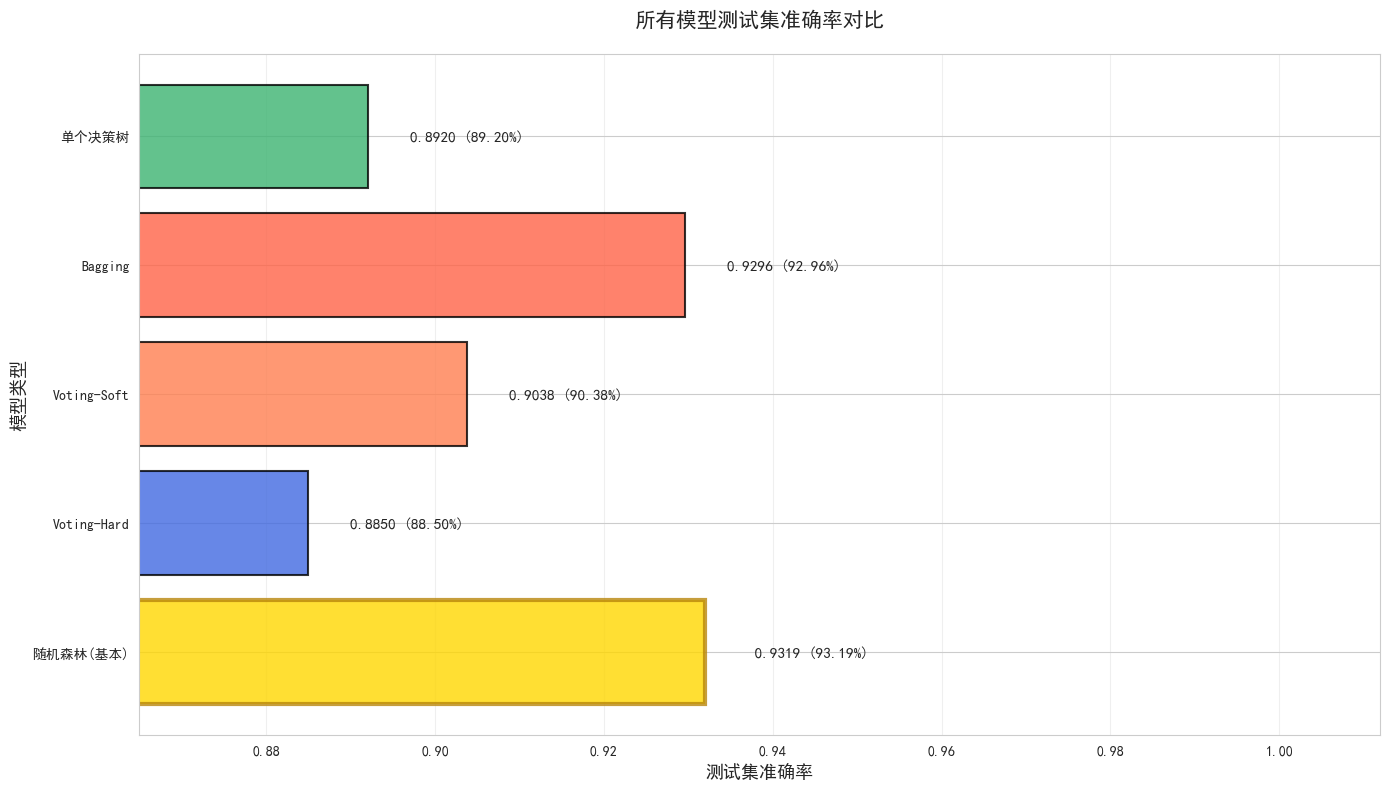


各类别准确率对比表：

正常(1)类别：
  随机森林                :  97.89%
  Voting-Soft         :  93.67%
  Bagging             :  96.08%

可疑(2)类别：
  随机森林                :  69.49%
  Voting-Soft         :  77.97%
  Bagging             :  77.97%

病理(3)类别：
  随机森林                :  88.57%
  Voting-Soft         :  80.00%
  Bagging             :  88.57%


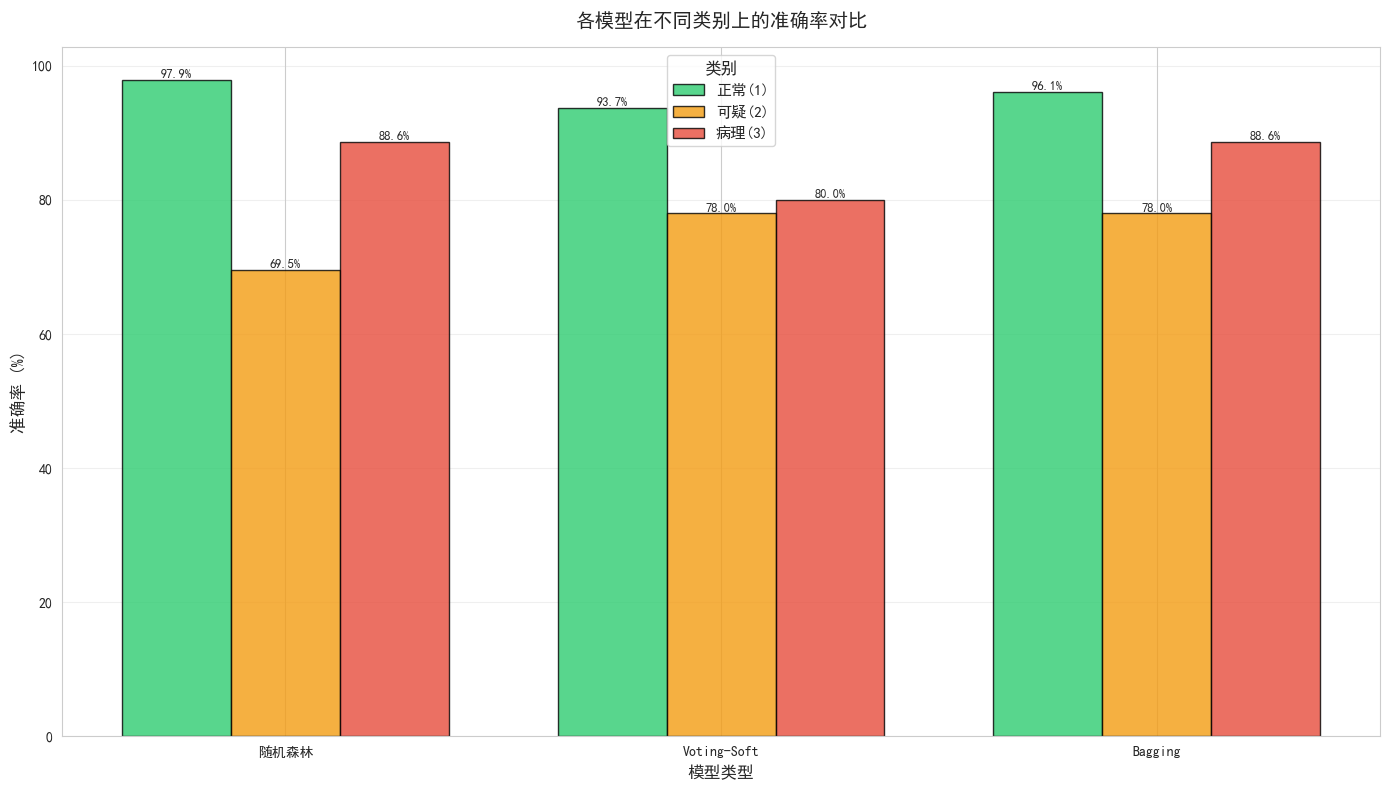


各类别性能分析：

正常(1)类别：
  最佳模型：随机森林 (97.89%)
  最差模型：Voting-Soft (93.67%)
  性能差异：4.22%

可疑(2)类别：
  最佳模型：Voting-Soft (77.97%)
  最差模型：随机森林 (69.49%)
  性能差异：8.47%

病理(3)类别：
  最佳模型：随机森林 (88.57%)
  最差模型：Voting-Soft (80.00%)
  性能差异：8.57%

模型复杂度分析（基学习器数量）：
  随机森林                : 100 个基学习器
  Voting-Hard         : 3 个不同类型的基学习器
  Voting-Soft         : 3 个不同类型的基学习器
  Bagging             : 100 棵决策树
  单个决策树               : 1 个基学习器


In [196]:
# 三种集成方法综合对比分析
# 整理所有模型的准确率
model_names = [
    '随机森林(基本)',
    'Voting-Hard',
    'Voting-Soft',
    'Bagging',
    '单个决策树'
]

model_accuracies = [
    test_accuracy_rf,
    test_accuracy_voting_hard,
    test_accuracy_voting_soft,
    test_accuracy_bagging,
    acc_single_tree
]

# 创建对比数据框
comparison_table = pd.DataFrame({
    '模型': model_names,
    '测试集准确率': model_accuracies,
    '准确率(%)': [f'{acc*100:.2f}%' for acc in model_accuracies]
}).sort_values('测试集准确率', ascending=False).reset_index(drop=True)

comparison_table['排名'] = range(1, len(comparison_table) + 1)
comparison_table = comparison_table[['排名', '模型', '测试集准确率', '准确率(%)']]

print("\n所有模型准确率排名：")
print(comparison_table.to_string(index=False))

# 找出最佳模型
best_model_idx = np.argmax(model_accuracies)
best_model_name = model_names[best_model_idx]
best_model_acc = model_accuracies[best_model_idx]

print(f"\n最佳模型：{best_model_name}")
print(f"  测试集准确率：{best_model_acc:.4f} ({best_model_acc*100:.2f}%)")

# 准确率可视化对比
# 创建颜色映射
colors_list = ['steelblue', 'royalblue', 'coral', 'tomato', 'mediumseagreen', 'lightcoral']

plt.figure(figsize=(14, 8))
bars = plt.barh(model_names, model_accuracies, color=colors_list, 
                alpha=0.8, edgecolor='black', linewidth=1.5)

# 高亮最佳模型
bars[best_model_idx].set_color('gold')
bars[best_model_idx].set_edgecolor('darkgoldenrod')
bars[best_model_idx].set_linewidth(3)

# 添加数值标签
for i, (bar, acc) in enumerate(zip(bars, model_accuracies)):
    width = bar.get_width()
    label = f'{acc:.4f} ({acc*100:.2f}%)'
    if i == best_model_idx:
        label = f' {label} '
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2.,
             label, ha='left', va='center', fontsize=11, fontweight='bold')

plt.xlabel('测试集准确率', fontsize=13)
plt.ylabel('模型类型', fontsize=13)
plt.title('所有模型测试集准确率对比', fontsize=15, fontweight='bold', pad=20)
plt.xlim([min(model_accuracies) - 0.02, max(model_accuracies) + 0.08])
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 各类别性能详细对比
# 计算每个模型在各类别上的准确率
class_names = ['正常(1)', '可疑(2)', '病理(3)']
models_for_class_comparison = ['随机森林', 'Voting-Soft', 'Bagging']
cms_for_comparison = [cm_rf, cm_voting_soft, cm_bagging]

class_accuracies = {}
for class_idx, class_name in enumerate(class_names):
    class_accuracies[class_name] = []
    for cm in cms_for_comparison:
        total = cm[class_idx, :].sum()
        correct = cm[class_idx, class_idx]
        acc = correct / total * 100
        class_accuracies[class_name].append(acc)

# 创建各类别性能对比表
print("\n各类别准确率对比表：")
for class_name in class_names:
    print(f"\n{class_name}类别：")
    for model_name, acc in zip(models_for_class_comparison, class_accuracies[class_name]):
        print(f"  {model_name:20s}: {acc:6.2f}%")

# 可视化各类别性能对比
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(class_names))
width = 0.25

bars1 = ax.bar(x - width, class_accuracies['正常(1)'], width, 
               label='正常(1)', color='#2ecc71', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x, class_accuracies['可疑(2)'], width, 
               label='可疑(2)', color='#f39c12', alpha=0.8, edgecolor='black')
bars3 = ax.bar(x + width, class_accuracies['病理(3)'], width, 
               label='病理(3)', color='#e74c3c', alpha=0.8, edgecolor='black')

# 添加数值标签
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', 
                fontsize=9, fontweight='bold')

ax.set_xlabel('模型类型', fontsize=12)
ax.set_ylabel('准确率 (%)', fontsize=12)
ax.set_title('各模型在不同类别上的准确率对比', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models_for_class_comparison)
ax.legend(fontsize=11, title='类别', title_fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 分析各类别性能
print("\n各类别性能分析：")
for class_name in class_names:
    best_idx = np.argmax(class_accuracies[class_name])
    worst_idx = np.argmin(class_accuracies[class_name])
    print(f"\n{class_name}类别：")
    print(f"  最佳模型：{models_for_class_comparison[best_idx]} "
          f"({class_accuracies[class_name][best_idx]:.2f}%)")
    print(f"  最差模型：{models_for_class_comparison[worst_idx]} "
          f"({class_accuracies[class_name][worst_idx]:.2f}%)")
    print(f"  性能差异：{class_accuracies[class_name][best_idx] - class_accuracies[class_name][worst_idx]:.2f}%")


# 估算模型复杂度（基学习器数量）
model_complexity = {
    '随机森林': rf_basic.n_estimators,
    'Voting-Hard': 3,  # 3个不同的基学习器
    'Voting-Soft': 3,
    'Bagging': bagging_clf.n_estimators,
    '单个决策树': 1
}

print("\n模型复杂度分析（基学习器数量）：")
for model, complexity in model_complexity.items():
    if model == '随机森林(基本)':
        print(f"  {model:20s}: {complexity} 棵决策树")
    elif model in ['Voting-Hard', 'Voting-Soft']:
        print(f"  {model:20s}: {complexity} 个不同类型的基学习器")
    elif model == 'Bagging':
        print(f"  {model:20s}: {complexity} 棵决策树")
    else:
        print(f"  {model:20s}: {complexity} 个基学习器")